In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import lightgbm as lgb
from sklearn.inspection import permutation_importance

### LightGBM Model Setup

In this section, we prepare the dataset for training a LightGBM classifier. LightGBM is a gradient boosting framework that is efficient and well-suited for large-scale tabular data.

We also ensure that the target labels are in the correct format for binary classification.

### Defining a Function to Assign Image Quadrants

This cell defines a helper function that assigns each observation to one of four quadrants based on its spatial position within an image.

For each image, the median values of the \(x\) and \(y\) coordinates are computed, and each point is classified into:

- \(Q1\),
- \(Q2\),
- \(Q3\),
- \(Q4\).

This grouping is later used to construct validation folds that preserve spatial structure.

In [120]:
def assign_quadrants(df):
    # Compute medians for each image
    medians = df.groupby('image_id')[['x', 'y']].median().rename(columns={'x': 'median_x', 'y': 'median_y'})
    df = df.merge(medians, left_on='image_id', right_index=True, how='left')
    
    # Assign quadrant based on image-specific medians
    def get_q(row):
        if row['x'] <= row['median_x'] and row['y'] <= row['median_y']:
            return 'Q1'
        elif row['x'] > row['median_x'] and row['y'] <= row['median_y']:
            return 'Q2'
        elif row['x'] <= row['median_x'] and row['y'] > row['median_y']:
            return 'Q3'
        else:
            return 'Q4'
    
    df['quadrant'] = df.apply(get_q, axis=1)
    df.drop(columns=['median_x', 'median_y'], inplace=True)
    return df

### Loading the Training and Test Data

In this cell, the training data are read from two CSV files and combined into one dataset.  
After that, quadrants are assigned to the training observations using the previously defined function.

The test dataset is then loaded separately.


Finally, non-predictive spatial and identifier columns such as `image_id`, `x`, and `y` are removed from the modeling datasets.

In [121]:
df_train_1 = pd.read_csv("../data/O012791.csv")
df_train_2 = pd.read_csv("../data/O013257.csv")


df_train = pd.concat([df_train_1, df_train_2], ignore_index=True)
df_train = assign_quadrants(df_train)

df_test = pd.read_csv("../data/O013490.csv")

df_train_filtered = df_train[df_train['expert_label'] != 0]

df_train_filtered["group"] = (
    df_train_filtered["image_id"].astype(str) + "_" + df_train_filtered["quadrant"].astype(str)
)
groups = df_train_filtered["group"]

df_train = df_train.drop(columns=["image_id", "y", "x"], errors="ignore")
df_test = df_test.drop(columns=["image_id", "y", "x"], errors="ignore")

/var/folders/r2/v9slb_c1705f5dy57j05v_qm0000gn/T/ipykernel_33283/2008958210.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_filtered["group"] = (


### Creating Feature Matrices and Target Variables

This cell prepares the final training and test inputs for the model.

Observations with `expert_label = 0` are excluded, since only labeled cloud and non-cloud pixels are used for classification.

Then:

- `X_train` and `X_test` contain the predictor variables,
- `y_train` and `y_test` contain the target labels.

The `quadrant` column is removed from the training predictors because it is only used for grouped validation and not as a model feature.

In [122]:
df_train_filtered = df_train[df_train['expert_label'] != 0]
df_test_filtered = df_test[df_test['expert_label'] != 0]



X_train = df_train_filtered.drop(['expert_label', 'quadrant'], axis=1)
y_train = df_train_filtered["expert_label"]

X_test = df_test_filtered.drop(['expert_label'], axis=1)
y_test = df_test_filtered["expert_label"]

### Hyperparameter Tuning with Grouped Cross-Validation

This cell performs hyperparameter tuning for the LightGBM classifier using `GridSearchCV`.

The following hyperparameters are tested:

- `num_leaves`,
- `learning_rate`.

To avoid data leakage caused by spatial dependence, `GroupKFold` is used instead of standard cross-validation.  
The grouping variable is the image quadrant, which ensures that entire spatial regions are separated across folds.

The best parameter combination and the corresponding validation score are printed at the end.

In [123]:


param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.05, 0.1, 0.15]
}

lgbm = lgb.LGBMClassifier(objective='binary', metric='accuracy', boosting_type='gbrt', verbose=-1)

groups = df_train_filtered['quadrant']
gkf = GroupKFold(n_splits=len(df_train_filtered['quadrant'].unique()))

# Set up GridSearchCV with the custom group split
grid_search = GridSearchCV(estimator=lgbm, 
                           param_grid=param_grid, 
                           cv=gkf,  # use GroupKFold here
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train, y_train, groups=groups)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best AUC score: {grid_search.best_score_:.4f}")

Fitting 4 folds for each of 9 candidates, totalling 36 fits
Best parameters: {'learning_rate': 0.15, 'num_leaves': 15}
Best AUC score: 0.9310


In [124]:
best_params = grid_search.best_params_

params_lgb = {
    'objective': 'binary',
    'metric': 'accuracy',
    'boosting_type': 'gbrt',
    'verbose': -1,
}

params_lgb.update(best_params)

params_lgb

{'objective': 'binary',
 'metric': 'accuracy',
 'boosting_type': 'gbrt',
 'verbose': -1,
 'learning_rate': 0.15,
 'num_leaves': 15}

### Training the Full LightGBM Model and Evaluating Feature Importance

In this cell, the target labels are converted from \(\{-1, 1\}\) to \(\{0, 1\}\), since LightGBM expects binary labels in numeric form.

A LightGBM model is then trained on the full training feature set.

After fitting the model, feature importance values are extracted and ranked.  
The top 25 most important predictors are visualized in a bar plot.

Finally, a subset of the most important features is selected for further experiments with reduced feature spaces.

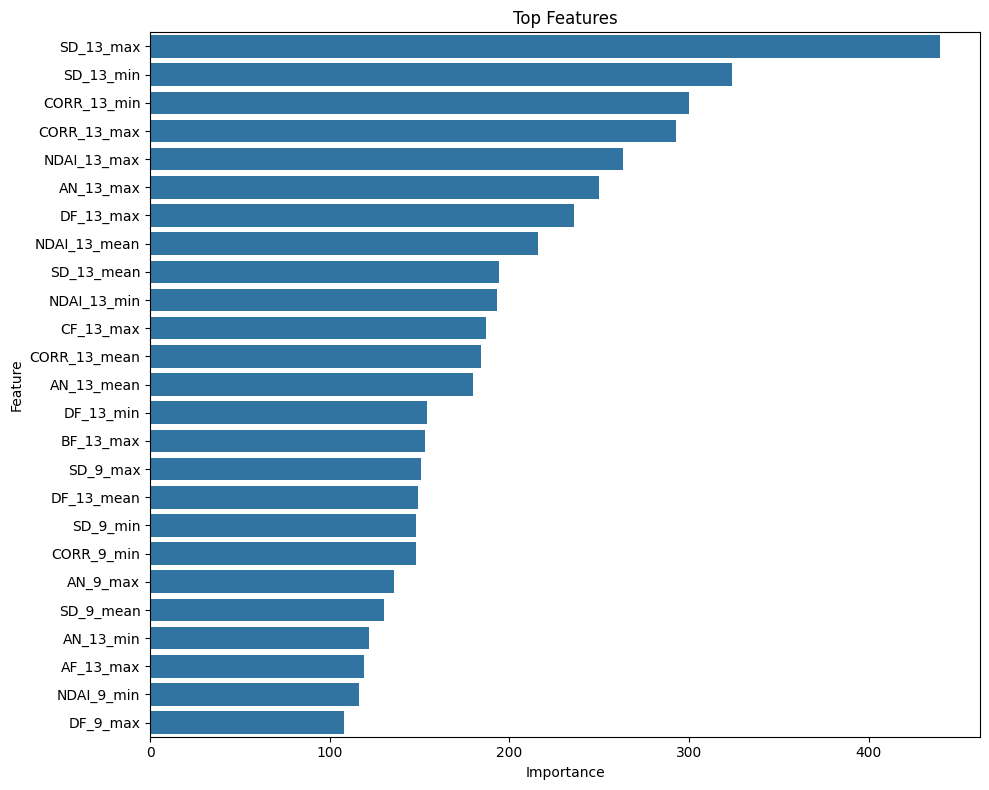

In [125]:
y_train_lgb = y_train.copy()
y_test_lgb = y_test.copy()

y_train_lgb = y_train_lgb.replace(-1, 0)
y_test_lgb = y_test_lgb.replace(-1, 0)

y_train_lgb = y_train.replace(-1, 0)
y_test_lgb = y_test.replace(-1, 0)
lgb_model_full = lgb.LGBMClassifier(**params_lgb, n_estimators=1000)
lgb_model_full.fit(X_train, y_train_lgb)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model_full.feature_importances_
}).sort_values('importance', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(25),
    x='importance',
    y='feature'
)
plt.title('Top Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features = feature_importance.head(105)['feature'].tolist()

top_features_cleaned = [
    f for f in top_features
    if not any(prefix in f for prefix in ["AF_", "BF_", "CF_", "DF_", "AN_"])
]

### Training and Evaluating the Model with Selected Top Features

This cell trains a LightGBM classifier using only the selected top features.

After fitting the model, predictions are generated for the test set and the following evaluation metrics are reported:

- classification report,
- confusion matrix,
- accuracy.

This step helps assess whether a reduced feature set can achieve strong predictive performance while simplifying the model.

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98     42830
         1.0       0.97      0.99      0.98     39253

    accuracy                           0.98     82083
   macro avg       0.98      0.98      0.98     82083
weighted avg       0.98      0.98      0.98     82083



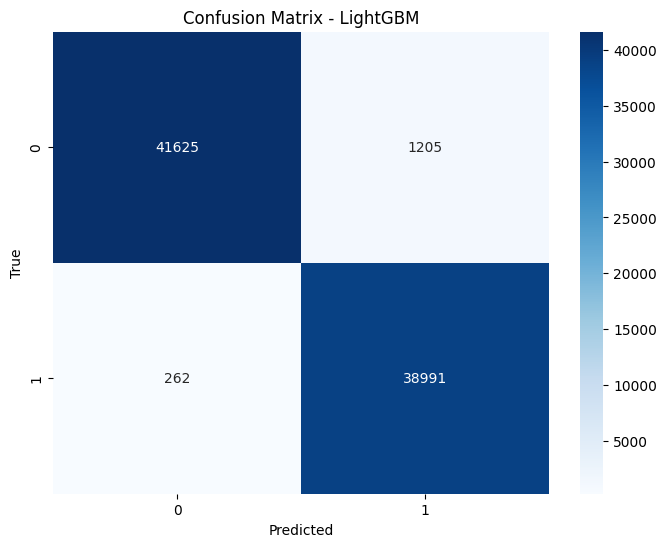

Accuracy: 0.9821278462044516


In [126]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

lgb_model = lgb.LGBMClassifier(**params_lgb, n_estimators=1000)
lgb_model.fit(X_train_top, y_train_lgb)


y_pred = lgb_model.predict(X_test_top)

print("Classification Report:")
print(classification_report(y_test_lgb, y_pred))

cm = confusion_matrix(y_test_lgb, y_pred)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - LightGBM")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

accuracy = accuracy_score(y_test_lgb, y_pred)
print("Accuracy:", accuracy)

### Training the Model with a Cleaned Feature Subset

This cell repeats the LightGBM training process using a cleaned subset of selected features.

The model is fitted on the reduced training matrix and then evaluated on the test set using:

- the classification report,
- the confusion matrix,
- overall accuracy.

This allows comparison between the original selected feature set and the cleaned version.

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99     42830
         1.0       0.97      1.00      0.99     39253

    accuracy                           0.99     82083
   macro avg       0.99      0.99      0.99     82083
weighted avg       0.99      0.99      0.99     82083



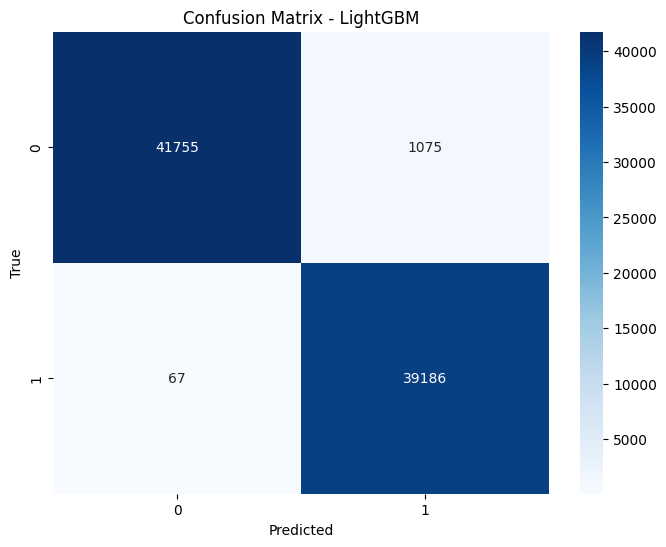

Accuracy: 0.9860872531462057


In [127]:
X_train_top = X_train[top_features_cleaned]
X_test_top = X_test[top_features_cleaned]

lgb_model = lgb.LGBMClassifier(**params_lgb, n_estimators=1000)
lgb_model.fit(X_train_top, y_train_lgb)


y_pred = lgb_model.predict(X_test_top)

print("Classification Report:")
print(classification_report(y_test_lgb, y_pred))

cm = confusion_matrix(y_test_lgb, y_pred)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - LightGBM")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

accuracy = accuracy_score(y_test_lgb, y_pred)
print("Accuracy:", accuracy)

In [128]:
import joblib


joblib.dump(lgb_model, "lgb_model.pkl")


loaded_model = joblib.load("lgb_model.pkl")


y_pred_loaded = loaded_model.predict(X_test_top)

### Constructing a Post-hoc and Error Analysis Dataset

In this cell, model predictions are transformed back from \(\{0,1\}\) to \(\{-1,1\}\) so that they match the original class labels.

A new dataset is then created containing:

- spatial coordinates \((x, y)\),
- true labels,
- predicted labels.

Based on the comparison between true and predicted classes, each observation is assigned to one of four categories:

- True Positive (TP),
- True Negative (TN),
- False Positive (FP),
- False Negative (FN).

This structure is useful for visualizing where the model makes correct and incorrect predictions in the image.

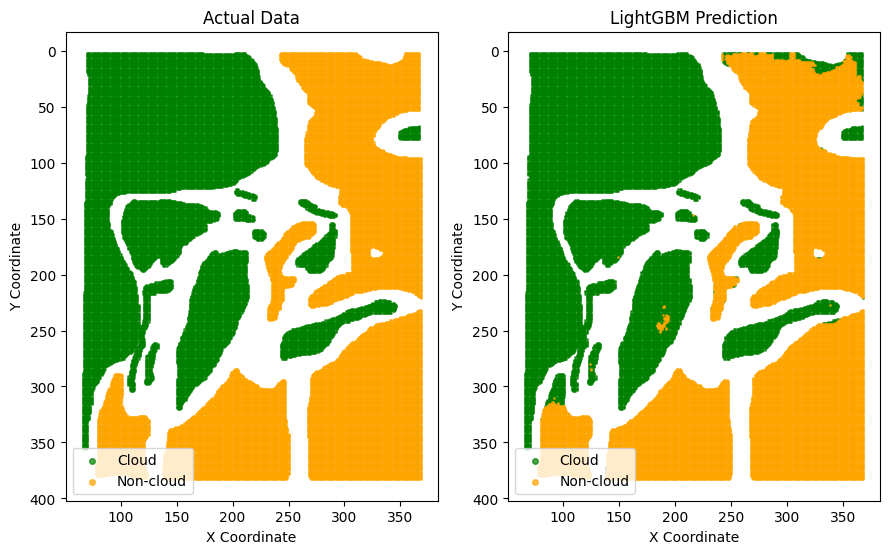

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


y_pred = np.array(y_pred).copy()
y_pred[y_pred == 0] = -1

y_test_arr = np.array(y_test).copy()


results_test = pd.read_csv("../data/O013490.csv")
results_test = results_test[results_test["expert_label"] != 0][["x", "y"]].copy()

results_test["y_test"] = y_test_arr
results_test["y_pred"] = y_pred


results_test["error_type"] = None

results_test.loc[
    (results_test["y_test"] == 1) & (results_test["y_pred"] == 1),
    "error_type"
] = "TP"

results_test.loc[
    (results_test["y_test"] == -1) & (results_test["y_pred"] == -1),
    "error_type"
] = "TN"

results_test.loc[
    (results_test["y_test"] == -1) & (results_test["y_pred"] == 1),
    "error_type"
] = "FP"

results_test.loc[
    (results_test["y_test"] == 1) & (results_test["y_pred"] == -1),
    "error_type"
] = "FN"


fig, axes = plt.subplots(1, 2, figsize=(9, 6))
titles = ["Actual Data", "LightGBM Prediction"]

colors = {1: "green", -1: "orange"}
label_cols = ["y_test", "y_pred"]

for l, ax in enumerate(axes.flat):
    x = results_test["x"]
    y = results_test["y"]
    labels = results_test[label_cols[l]]

    for cls, color in colors.items():
        mask = labels == cls
        ax.scatter(
            x[mask],
            y[mask],
            c=color,
            s=1,
            alpha=0.7,
            label="Cloud" if cls == 1 else "Non-cloud"
        )

    ax.set_title(titles[l], fontsize=12)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.set_aspect("equal")
    ax.invert_yaxis()

    handles, labs = ax.get_legend_handles_labels()
    by_label = dict(zip(labs, handles))
    ax.legend(by_label.values(), by_label.keys(), markerscale=4)

plt.tight_layout()
plt.show()



### Visualizing an Engineered Feature in Spatial Coordinates

This cell defines a function for visualizing the spatial distribution of a chosen engineered feature.

For a selected feature, the values are plotted over the original image coordinates using a color scale.  
This allows us to inspect how the feature varies across the image and whether it captures meaningful spatial patterns.

In the example shown here, the feature `SD_13_mean` is visualized.

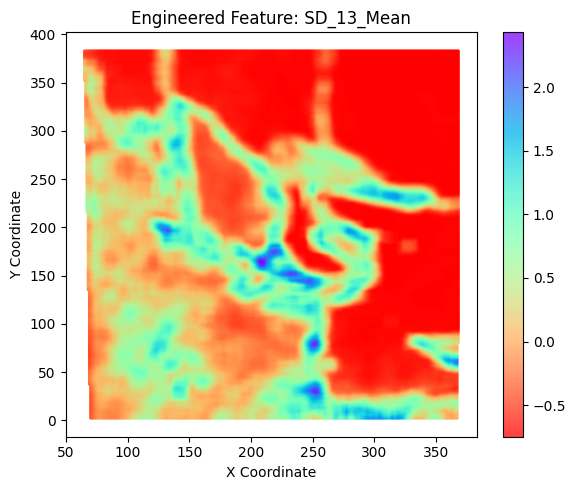

In [130]:
def visualize_feature(feature_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    df_feature = pd.read_csv("../data/O013490.csv")

    x = np.array(df_feature["x"])
    y = np.array(df_feature["y"])
    labels = np.array(df_feature[feature_name])

    sc = ax.scatter(x, y, c = labels, s = 1, cmap='rainbow_r', alpha=0.75)
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title("Engineered Feature: SD_13_Mean")
    plt.colorbar(sc)
    plt.tight_layout()
    plt.show()

visualize_feature("SD_13_mean")

### Computing Permutation Importance

This cell evaluates feature importance using permutation importance on the test set.

The idea is to randomly shuffle one feature at a time and measure the drop in model accuracy.  
Features whose permutation causes a larger decrease in performance are considered more important.

The results are then compared with the built-in LightGBM feature importance values using side-by-side visualizations.

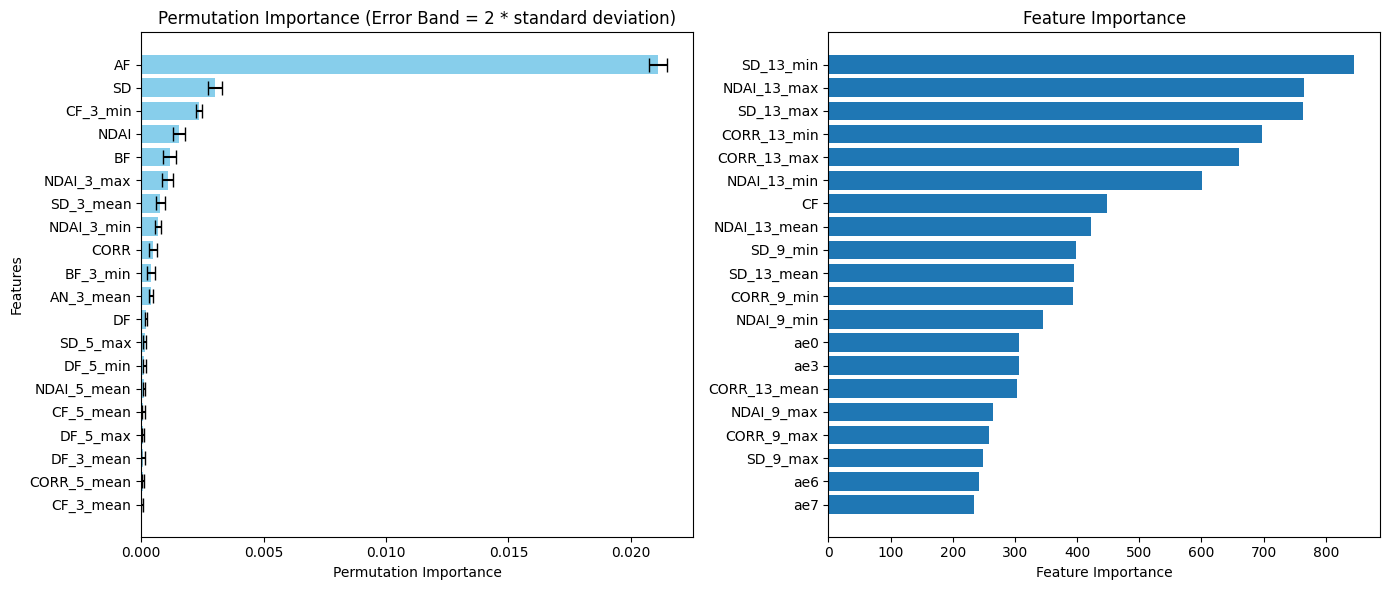

In [134]:
perm_importance_rf = permutation_importance(lgb_model, X_test_top, y_test, scoring="accuracy", n_repeats = 5, random_state = 1)
sorted_idx_rf = perm_importance_rf.importances_mean.argsort()[::-1][:20]
perm_feature_names_rf = X_train.columns[sorted_idx_rf]

feature_importance_rf = pd.DataFrame({
    'feature': X_test_top.columns,
    'importance': lgb_model.feature_importances_
})
feature_importance_rf = feature_importance_rf.sort_values('importance', ascending=False)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Permutation Importance
axes[0].barh(perm_feature_names_rf, perm_importance_rf.importances_mean[sorted_idx_rf], 
             xerr=perm_importance_rf.importances_std[sorted_idx_rf] * 2, capsize=5, 
             color='skyblue')
axes[0].set_xlabel("Permutation Importance")
axes[0].set_ylabel("Features")
axes[0].set_title("Permutation Importance (Error Band = 2 * standard deviation)")
axes[0].invert_yaxis()

# Feature Importance
axes[1].barh(feature_importance_rf["feature"], feature_importance_rf["importance"])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Feature Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()